# VocalPath: Exploratory Data Analysis

Analysis of synthetic acoustic biomarker data for voice pathology classification.
Features are modeled on published clinical ranges from Teixeira et al. (2013), Godino-Llorente et al. (2006), and Martinez et al. (2012).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/features.csv')
df['label_name'] = df['label'].map({0: 'Healthy', 1: 'Pathological'})
print(f'Dataset: {df.shape[0]} samples, {df.shape[1]-2} features')
print(f'\nClass distribution:\n{df["label_name"].value_counts()}')
df.describe().round(4)

Dataset: 600 samples, 26 features

Class distribution:
label_name
Pathological    306
Healthy         294
Name: count, dtype: int64


,f0_mean,f0_std,jitter_local,jitter_rap,shimmer_local,shimmer_apq3,hnr,mfcc_1,mfcc_2,mfcc_3,...,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,spectral_bandwidth,spectral_flatness,spectral_rolloff,zcr,rms,label
count,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,...,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000,600.0000
mean,173.0381,4.8407,0.0075,0.0046,0.0387,0.0211,18.9845,-227.1226,43.0929,-12.6413,...,-3.7858,0.9099,-2.0322,1662.9622,1954.1739,0.0371,3252.8685,0.0623,0.0682,0.5100
std,66.7266,3.0759,0.0052,0.0033,0.0247,0.0132,5.8503,57.5257,35.5090,24.7209,...,8.2109,6.8568,7.2895,477.5118,401.1461,0.0246,908.3382,0.0286,0.0328,0.5003
min,50.0000,0.1000,0.0001,0.0001,0.0010,0.0010,0.5267,-408.0032,-86.0050,-78.0227,...,-30.5623,-20.0057,-23.0231,404.7421,867.6657,0.0010,902.8175,0.0010,0.0010,0.0000
25%,128.7402,2.5894,0.0039,0.0022,0.0208,0.0125,15.0255,-266.1244,20.6945,-28.4998,...,-9.3766,-3.7718,-6.5612,1346.8378,1678.3639,0.0187,2616.2259,0.0438,0.0458,0.0000
50%,170.4644,4.5404,0.0067,0.0040,0.0346,0.0183,18.9366,-228.5341,41.2080,-13.7980,...,-3.3314,0.8783,-1.8075,1654.7218,1974.8029,0.0328,3249.9092,0.0597,0.0683,1.0000
75%,214.8104,6.5265,0.0102,0.0065,0.0536,0.0281,22.8566,-186.5012,65.5040,2.9997,...,1.5580,5.3778,2.7983,1972.8821,2217.8543,0.0523,3855.3770,0.0786,0.0888,1.0000
max,391.2466,17.9475,0.0250,0.0170,0.1206,0.0891,34.8746,-31.7308,150.6611,65.9890,...,29.2066,21.2089,17.7136,3008.4530,3217.2009,0.1172,6158.6112,0.1634,0.1813,1.0000


## 1. Key Biomarker Distributions

These are the primary clinical features used in voice pathology assessment. Overlap between classes reflects real-world diagnostic difficulty.

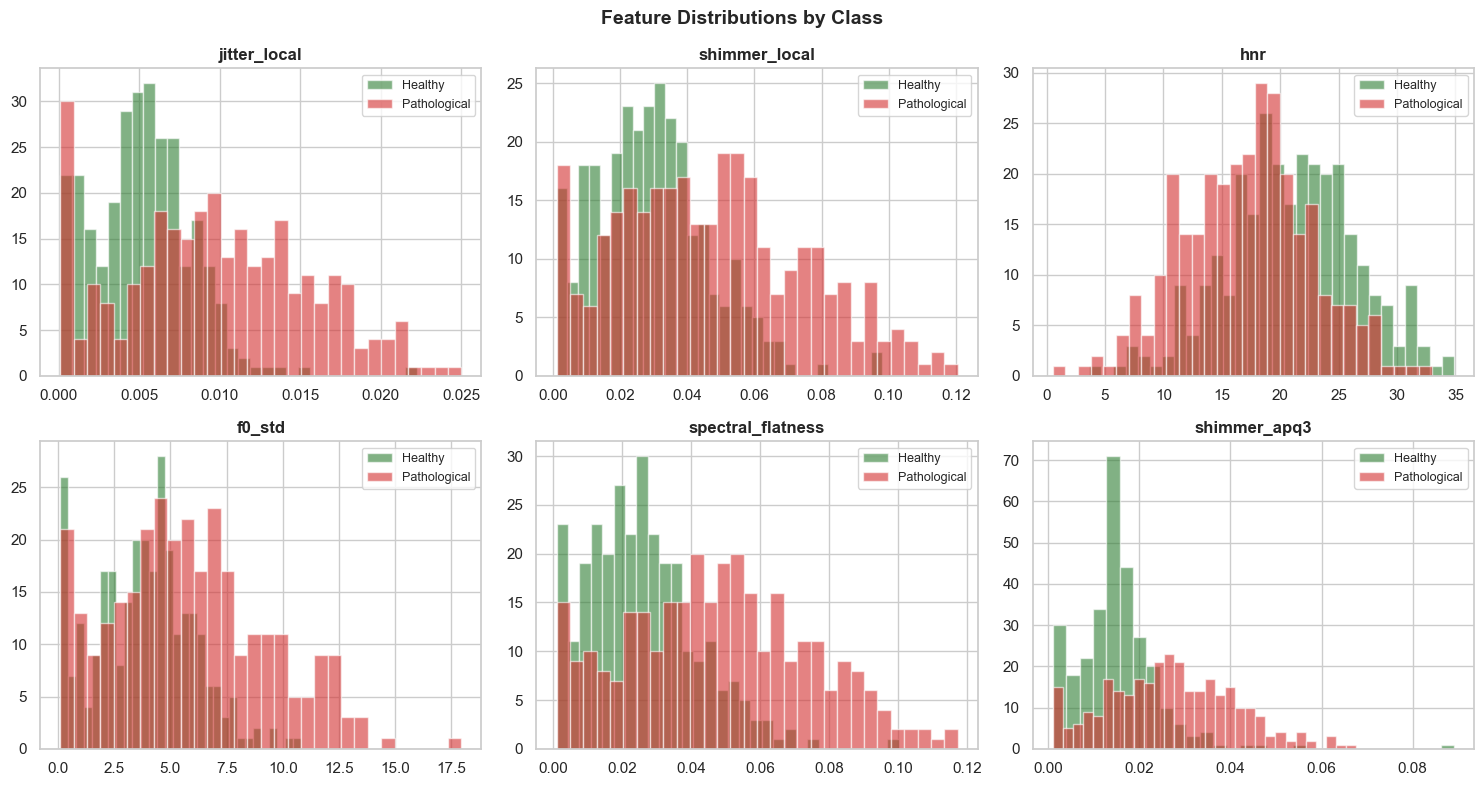

In [2]:
key_features = ['jitter_local', 'shimmer_local', 'hnr', 'f0_std', 'spectral_flatness', 'shimmer_apq3']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, key_features):
    for label, color in [(0, '#2e7d32'), (1, '#d32f2f')]:
        subset = df[df['label'] == label]
        ax.hist(subset[feat], bins=30, alpha=0.6, color=color,
                label='Healthy' if label == 0 else 'Pathological')
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **Shimmer (local, APQ3)** and **Jitter** show clear separation between classes, consistent with Teixeira et al. (2013)
- **HNR** is lower in pathological voices (more noise in the signal), as expected
- **Spectral flatness** increases in pathological voices, reflecting noisier spectral content
- All features show substantial overlap, reflecting real clinical difficulty in distinguishing mild dysphonia from normal variation

## 2. Box Plots of Clinical Biomarkers

C:\Users\lberin\AppData\Local\Temp\ipykernel_2380\2579481865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label_name', y=feat, ax=ax,
C:\Users\lberin\AppData\Local\Temp\ipykernel_2380\2579481865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label_name', y=feat, ax=ax,
C:\Users\lberin\AppData\Local\Temp\ipykernel_2380\2579481865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label_name', y=feat, ax=ax,
C:\Users\lberin\AppData\Local\Temp\ipykernel_2380\2579481865.py:3: FutureWarning: 

Pass

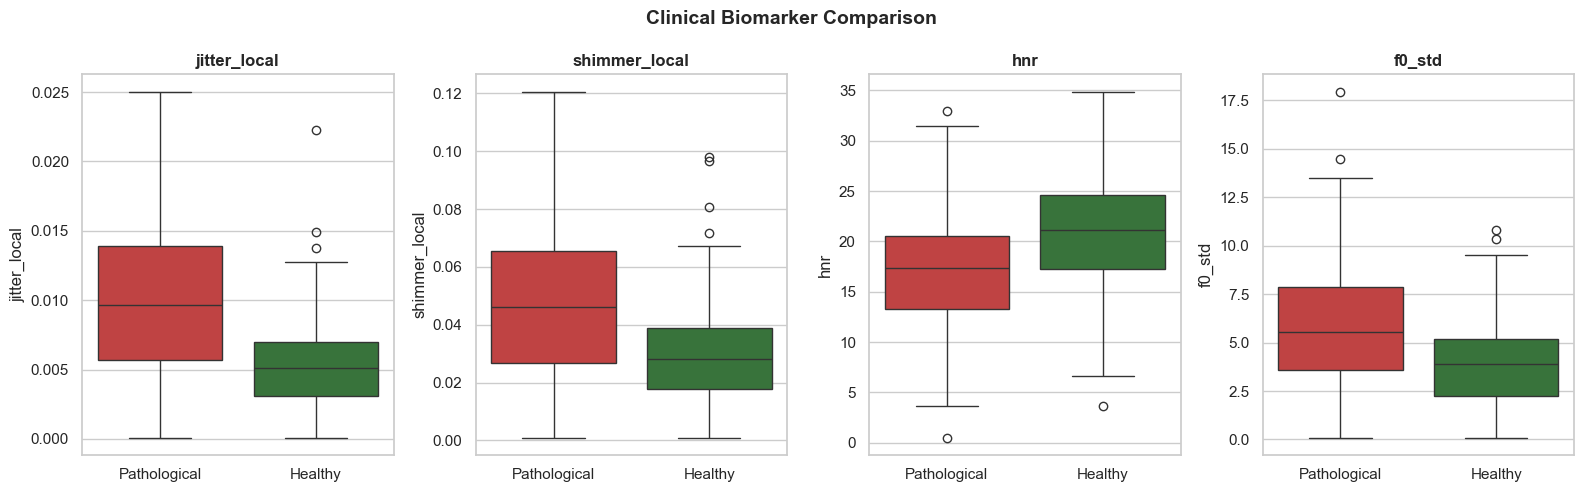

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feat in zip(axes, ['jitter_local', 'shimmer_local', 'hnr', 'f0_std']):
    sns.boxplot(data=df, x='label_name', y=feat, ax=ax,
                palette={'Healthy': '#2e7d32', 'Pathological': '#d32f2f'})
    ax.set_xlabel('')
    ax.set_title(feat, fontweight='bold')
plt.suptitle('Clinical Biomarker Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Correlation Matrix

Inter-feature correlations are expected due to the shared latent severity factor in the data generation model, and match real clinical data where jitter, shimmer, and HNR co-vary.

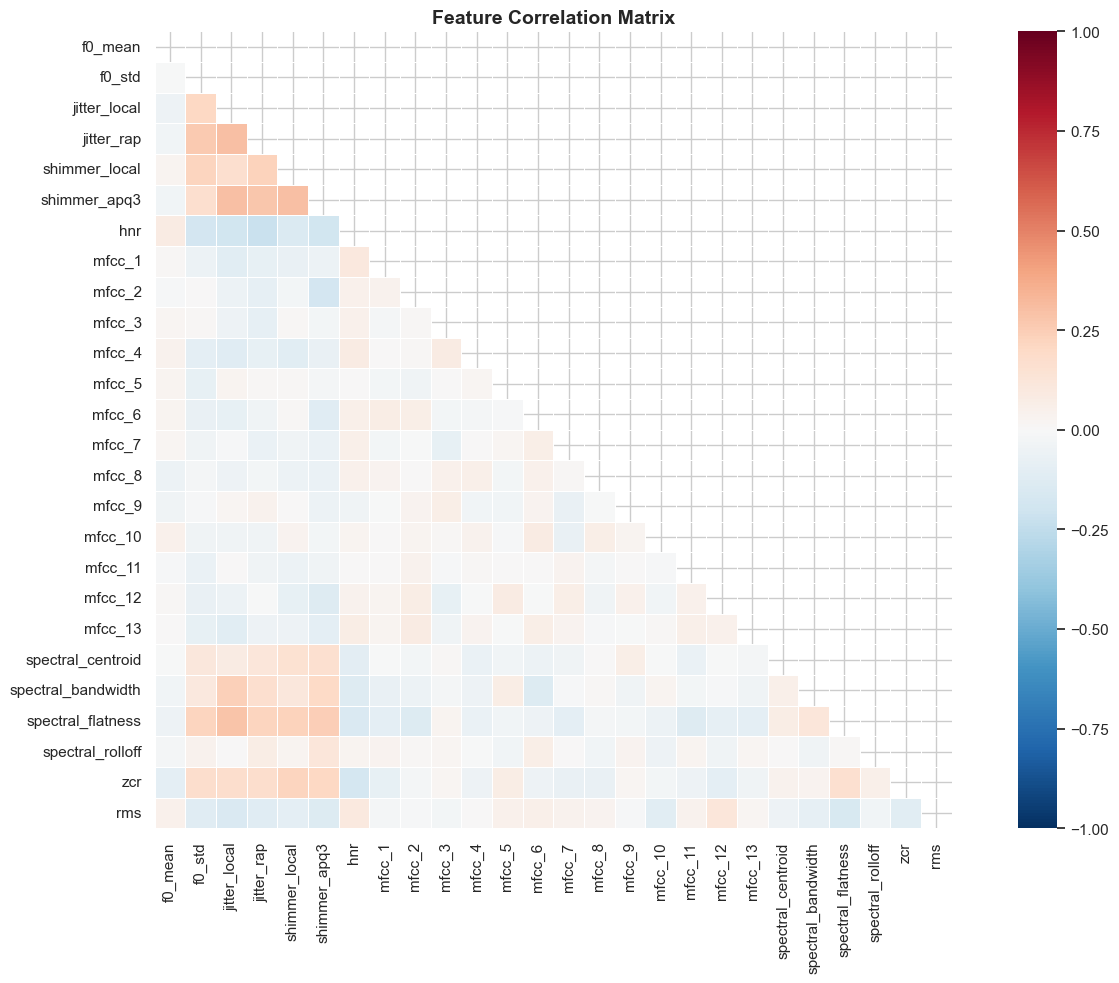

In [4]:
feature_cols = [c for c in df.columns if c not in ['label', 'label_name']]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot=False, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Class Separability (2D Projections)

Visualize how well the two most important features separate the classes.

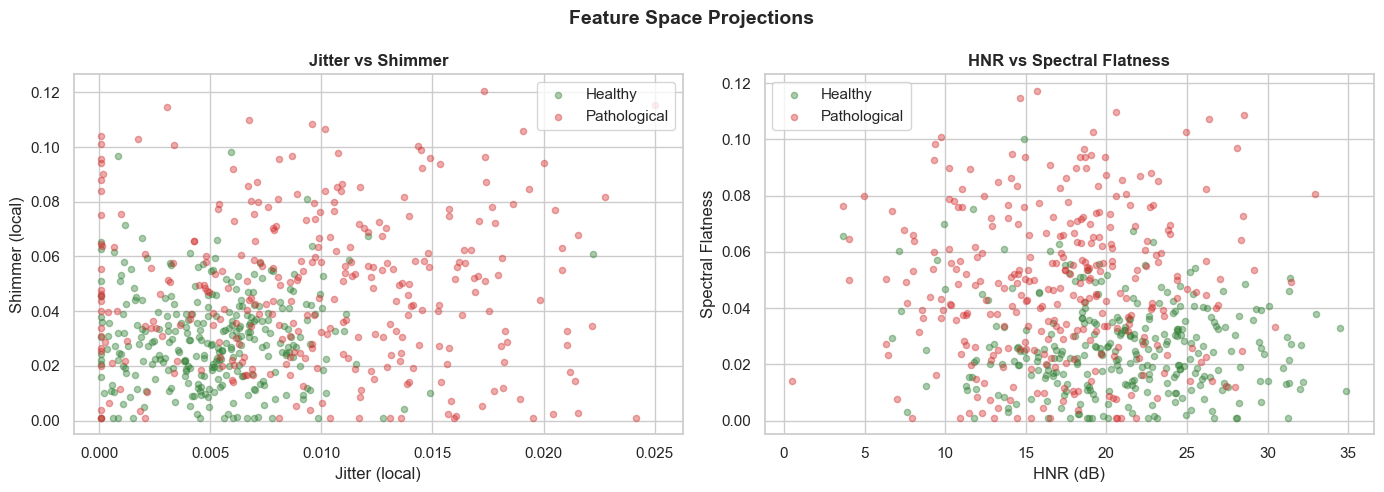

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jitter vs Shimmer
for label, color, name in [(0, '#2e7d32', 'Healthy'), (1, '#d32f2f', 'Pathological')]:
    sub = df[df['label'] == label]
    axes[0].scatter(sub['jitter_local'], sub['shimmer_local'], c=color,
                    alpha=0.4, s=20, label=name)
axes[0].set_xlabel('Jitter (local)')
axes[0].set_ylabel('Shimmer (local)')
axes[0].set_title('Jitter vs Shimmer', fontweight='bold')
axes[0].legend()

# HNR vs Spectral Flatness
for label, color, name in [(0, '#2e7d32', 'Healthy'), (1, '#d32f2f', 'Pathological')]:
    sub = df[df['label'] == label]
    axes[1].scatter(sub['hnr'], sub['spectral_flatness'], c=color,
                    alpha=0.4, s=20, label=name)
axes[1].set_xlabel('HNR (dB)')
axes[1].set_ylabel('Spectral Flatness')
axes[1].set_title('HNR vs Spectral Flatness', fontweight='bold')
axes[1].legend()

plt.suptitle('Feature Space Projections', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Takeaways:**
- Perturbation measures (jitter, shimmer) and spectral flatness are the strongest discriminators
- Significant class overlap exists, especially in MFCC features and temporal measures
- The overlap is clinically realistic — mild voice pathology is genuinely difficult to distinguish from normal vocal variation
- Inter-feature correlations (e.g., high jitter + high shimmer + low HNR) match known clinical patterns